In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("loan.csv")
df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split 
from sklearn import svm 
from sklearn.metrics import accuracy_score

In [6]:
df.shape

(614, 13)

In [7]:
 df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
df.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_25428\1100601323.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)


In [15]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [16]:
df["Dependents"].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [19]:
df.replace(to_replace='3+' , value=4 , inplace=True)

In [20]:
df["Dependents"].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

<Axes: xlabel='Education', ylabel='count'>

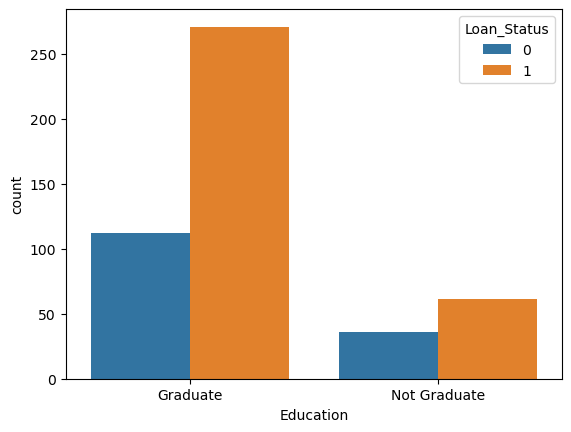

In [21]:
sns.countplot(x="Education" , hue = "Loan_Status" , data = df)

<Axes: xlabel='Married', ylabel='count'>

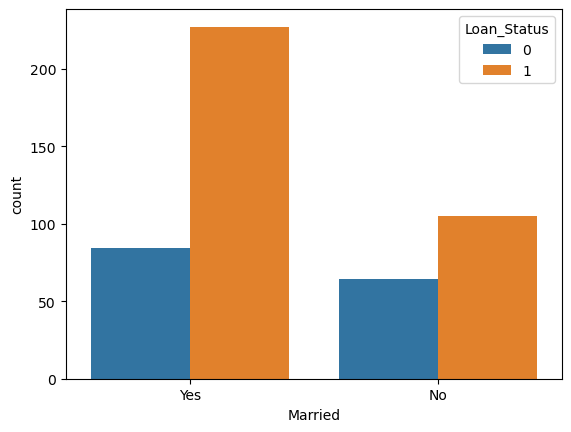

In [22]:
sns.countplot(x="Married" , hue = "Loan_Status" , data = df)

In [23]:
df.replace({"Married":{"No":0,"Yes":1}},inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_25428\3433203901.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Married":{"No":0,"Yes":1}},inplace=True)


In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,1,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [25]:
df.replace({"Education":{"Not Graduate":0,"Graduate":1}},inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_25428\391815038.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Education":{"Not Graduate":0,"Graduate":1}},inplace=True)


In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,1,1,1,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,1,2,1,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [27]:
df.replace({"Self_Employed":{"No":0,"Yes":1}},inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_25428\556260644.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Self_Employed":{"No":0,"Yes":1}},inplace=True)


In [28]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1


In [30]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1


In [32]:
df['is_male'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [33]:
df.drop('Gender', axis=1, inplace=True)

In [34]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,is_male
1,LP001003,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0,1
2,LP001005,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1,1
3,LP001006,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1,1
4,LP001008,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1,1
5,LP001011,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1,1


In [35]:
df.replace({"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_25428\4215048212.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)


In [36]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,is_male
1,LP001003,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,1
2,LP001005,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,1
3,LP001006,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,1
4,LP001008,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,1
5,LP001011,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1,1


In [38]:
x = df.drop(columns = ['Loan_ID' , "Loan_Status"])
y = df['Loan_Status']

In [46]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.1 , random_state = 42 , stratify=y)

In [48]:
x.shape , x_train.shape , x_test.shape

((480, 11), (432, 11), (48, 11))

In [50]:
model = svm.SVC(kernel="linear")

In [51]:
model.fit(x_train , y_train)

SVC(kernel='linear')

In [60]:
x_train_pred = model.predict(x_train)

In [62]:
train_accuracy = accuracy_score(x_train_pred , y_train)
train_accuracy

0.8032407407407407

In [67]:
x_test_pred = model.predict(x_test)

In [68]:
test_accuracy = accuracy_score(x_test_pred , y_test)
test_accuracy

0.7916666666666666